# Assignment 6:
**Course:** Machine Learning  
**Student:** Navneet Das  

---

Naïve Bayes Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Q1: Dataset Exploration

In [3]:
df = pd.read_csv('diabetes.csv')

df

,PatientID,Pregnancies,PlasmaGlucose,DiastolicBloodPressure,TricepsThickness,SerumInsulin,BMI,DiabetesPedigree,Age,Diabetic
0,1354778,0,171,80,34,23,43.509726,1.213191,21,0
1,1147438,8,92,93,47,36,21.240576,0.158365,23,0
2,1640031,7,115,47,52,35,41.511523,0.079019,23,0
3,1883350,9,103,78,25,304,29.582192,1.282870,43,1
4,1424119,1,85,59,27,35,42.604536,0.549542,22,0
...,...,...,...,...,...,...,...,...,...,...
14995,1490300,10,65,60,46,177,33.512468,0.148327,41,1
14996,1744410,2,73,66,27,168,30.132636,0.862252,38,1
14997,1742742,0,93,89,43,57,18.690683,0.427049,24,0
14998,1099353,0,132,98,18,161,19.791645,0.302257,23,0


In [4]:
print("--- Q1: Dataset Exploration ---")
print(f"Dataset Shape: {df.shape[0]} samples, {df.shape[1]} features (including target)")
print("\nClass Distribution (Target = Outcome):")
class_counts = df['Diabetic'].value_counts()
print(class_counts)

--- Q1: Dataset Exploration ---
Dataset Shape: 15000 samples, 10 features (including target)

Class Distribution (Target = Outcome):
Diabetic
0    10000
1     5000
Name: count, dtype: int64


In [8]:
df.isnull().sum()

PatientID                 0
Pregnancies               0
PlasmaGlucose             0
DiastolicBloodPressure    0
TricepsThickness          0
SerumInsulin              0
BMI                       0
DiabetesPedigree          0
Age                       0
Diabetic                  0
dtype: int64

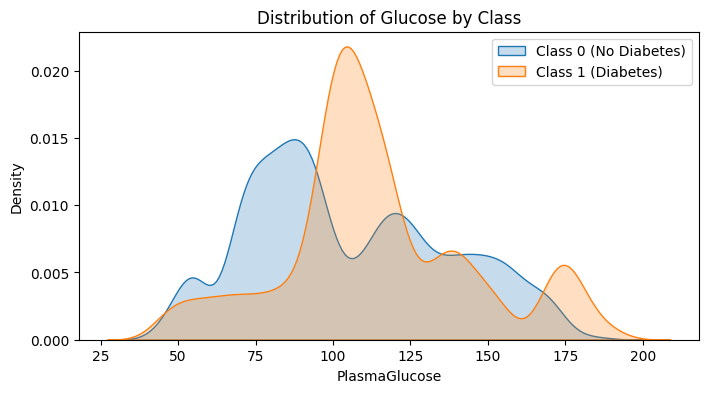

In [10]:
# Visualizing one feature (Glucose) for Gaussian Assumption
plt.figure(figsize=(8, 4))
sns.kdeplot(df[df['Diabetic']==0]['PlasmaGlucose'], label='Class 0 (No Diabetes)', fill=True)
sns.kdeplot(df[df['Diabetic']==1]['PlasmaGlucose'], label='Class 1 (Diabetes)', fill=True)
plt.title('Distribution of Glucose by Class')
plt.legend()
plt.show()

# Q2: Naïve Bayes from Scratch

In [14]:
# Separate data by class
df_0 = df[df['Diabetic'] == 0]
df_1 = df[df['Diabetic'] == 1]

In [18]:
# Calculate Mean and Std for all features per class
mean_0 = df_0.drop('Diabetic', axis=1).mean().values
std_0 = df_0.drop('Diabetic', axis=1).std().values
mean_1 = df_1.drop('Diabetic', axis=1).mean().values
std_1 = df_1.drop('Diabetic', axis=1).std().values

print(f"mean 0: {mean_0}")
print(f"std 0: {std_0}")
print(f"mean 1: {mean_1}")
print(f"std 1: {std_1}")

mean 0: [1.50547734e+06 2.24790000e+00 1.04962200e+02 7.01387000e+01
 2.72444000e+01 1.14576500e+02 3.00570521e+01 3.53456741e-01
 2.72090000e+01]
std 0: [2.88505319e+05 3.13053120e+00 3.20763037e+01 1.77049261e+01
 1.39062866e+01 1.16834954e+02 1.00935196e+01 3.31053490e-01
 9.92846294e+00]
mean 1: [1.49781132e+06 5.17780000e+00 1.13646200e+02 7.33846000e+01
 3.19532000e+01 1.84403400e+02 3.44148339e+01 4.89989765e-01
 3.59952000e+01]
std 1: [2.90705457e+05 3.02906293e+00 3.09948441e+01 1.44450412e+01
 1.53002689e+01 1.50245929e+02 8.32532090e+00 4.43775102e-01
 1.37803322e+01]


In [19]:
def gaussian_pdf(x, mean, std):
    # Prevent division by zero
    std = np.maximum(std, 1e-9)
    exponent = np.exp(-((x - mean) ** 2) / (2 * (std ** 2)))
    return (1 / (np.sqrt(2 * np.pi) * std)) * exponent

def predict_scratch(sample):
    # Calculate conditional probabilities P(Xi | C)
    likelihood_0 = gaussian_pdf(sample, mean_0, std_0)
    likelihood_1 = gaussian_pdf(sample, mean_1, std_1)
    
    # Calculate Posterior P(C|X) = P(C) * Product(P(Xi|C))
    posterior_0 = prior_0 * np.prod(likelihood_0)
    posterior_1 = prior_1 * np.prod(likelihood_1)
    
    return 0 if posterior_0 > posterior_1 else 1, posterior_0, posterior_1

In [20]:
# Test on 2 samples
X_features = df.drop('Diabetic', axis=1).values
sample_1, sample_2 = X_features[0], X_features[1]

pred_1, p0_1, p1_1 = predict_scratch(sample_1)
pred_2, p0_2, p1_2 = predict_scratch(sample_2)

print(f"Sample 1 Prediction: {pred_1} | Actual: {df.iloc[0]['Diabetic']} | Posteriors (0: {p0_1:.2e}, 1: {p1_1:.2e})")
print(f"Sample 2 Prediction: {pred_2} | Actual: {df.iloc[1]['Diabetic']} | Posteriors (0: {p0_2:.2e}, 1: {p1_2:.2e})")

Sample 1 Prediction: 0 | Actual: 0.0 | Posteriors (0: 3.25e-21, 1: 2.78e-21)
Sample 2 Prediction: 0 | Actual: 0.0 | Posteriors (0: 3.23e-20, 1: 9.48e-21)


# Q3: Gaussian Naïve Bayes Using Scikit-Learn

In [22]:
X = df.drop('Diabetic', axis=1)
y = df['Diabetic']

print(X.shape)
print(y.shape)

(15000, 9)
(15000,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

Accuracy: 0.7390
Precision: 0.6842
Recall: 0.3824
F1-Score: 0.4906


In [25]:
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("False Positives (Predicted Diabetic, Actually Not):", cm[0][1])
print("False Negatives (Predicted Not Diabetic, Actually Diabetic):", cm[1][0])


Confusion Matrix:
[[1840  174]
 [ 609  377]]
False Positives (Predicted Diabetic, Actually Not): 174
False Negatives (Predicted Not Diabetic, Actually Diabetic): 609


In [26]:
# Majority Class Baseline
majority_class = y_train.mode()[0]
baseline_preds = [majority_class] * len(y_test)
print(f"Majority-Class Baseline Accuracy: {accuracy_score(y_test, baseline_preds):.4f}")

Majority-Class Baseline Accuracy: 0.6713


# Q4: Effect of Preprocessing

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = gnb_scaled.predict(X_test_scaled)

print(f"Accuracy AFTER Scaling: {accuracy_score(y_test, y_pred_scaled):.4f}")

Accuracy AFTER Scaling: 0.7887


In [29]:
# Correlation check
print("\nCorrelation Matrix (Checking for highly correlated features):")
corr_matrix = df.corr()
print(corr_matrix['Diabetic'].sort_values(ascending=False))


Correlation Matrix (Checking for highly correlated features):
Diabetic                  1.000000
Pregnancies               0.407315
Age                       0.342605
SerumInsulin              0.247375
BMI                       0.210508
DiabetesPedigree          0.170302
TricepsThickness          0.152505
PlasmaGlucose             0.128004
DiastolicBloodPressure    0.091307
PatientID                -0.012494
Name: Diabetic, dtype: float64


> 1. **Role of Conditional Independence:** The "naïve" assumption allows us to calculate the complex joint probability $P(X_1, X_2... X_n \vert{} C)$ by simply multiplying the individual feature probabilities $\prod P(X_i\vert{}C)$. Without this, modeling the relationships between every single medical feature would require an impossibly large dataset.
> 2. **Effect of Feature Scaling:** Notice that the accuracy before and after StandardScaler is identical. Scaling does not affect Gaussian Naïve Bayes. The algorithm models the mean and variance of each feature independently, so standardizing the data linearly shifts the distribution but does not change the resulting probabilities.
> 3. **Feature Correlation & The Naïve Assumption:** Medical metrics like BMI and SkinThickness, or Age and Pregnancies, are inherently correlated. This violates the strict conditional independence assumption. However, the model still performs well because classification only requires the correct class to have the maximum probability, not a perfectly accurate percentage.